## **Multi-channel Marketing Attribution Model**
This project is a exploratory attempt on understanding rule-based attribution models in a controlled environment using AI-generated synthetic data about users touchpoints with paid Ads and conversions. The objective is understand how does each model changes the results and insights out of **multi-channel marketing strategy**.  

Three rule-based attribution models were applied: (1) First-touch, (2) Last-touch, and (3) Linear model.

This resource provides a high-level understanding of what are rule-based attribution model and its difference from a algorithmic data-driven attribution: https://blog.adobe.com/en/publish/2016/01/25/rules-based-vs-algorithmic-attribution


**Tech-stack:** Python, Pandas, Numpy, DuckDB, SQL, Seaborn, Matplot

#### **1. Generating Synthetic Data**


To evaluate multi-channel, this notebook utilizes a custom-built, funnel-biased synthetic data generator. The pipeline simulates a realistic multi-touch digital marketing ecosystem by generating two core relational datasets: user touchpoints and CRM conversions.

The data generation process is structured around the following programmatic steps:

* **User Base Simulation:** A distinct cohort of 1,000 unique users is established utilizing UUIDs to simulate anonymous web visitors.
* **Funnel-Positioned Probability Weighting:** Rather than assuming uniform randomness—which would artificially smooth out channel performance via the Law of Large Numbers—the generator applies distinct probability arrays using `numpy.random.choice` based on the user's sequential step in the conversion funnel:
* *First Touch (Discovery Phase):* Probabilities are heavily skewed toward top-of-funnel (ToFu) social and awareness channels (**LinkedIn Ads at 40%** and **Meta Ads at 35%**).
* *Middle Touches (Nurture Phase):* Probabilities shift toward mid-funnel (MiFu) research and retention channels (**Organic Search at 30%** and **Email at 20%**).
* *Last Touch (Closing Phase):* Probabilities favor high-intent, bottom-of-funnel (BoFu) demand capture (**Google Ads at 50%** and **Email at 25%**).


* **Variable Journey Lengths:** Each user is dynamically assigned a non-linear path consisting of 1 to 5 marketing interactions, mimicking erratic real-world consumer behavior.
* **CRM Conversion & Revenue Mapping:** A fixed conversion rate (30%) is applied across the user pool. For successful conversions, a timestamp-validated record is injected into a separate CRM table, assigning a randomized, continuous revenue value between **$500 and $5,000** to simulate varied contract sizes or order values.
* **Relational Data Decoupling:** The final output is written to two separate, flat CSV files (`raw_touchpoints_weighted.csv` and `raw_conversions_weighted.csv`). This decodes the relationship between touchpoints and sales, creating the exact siloed environment required to build and validate an ETL data warehousing pipeline.

In [21]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import uuid

# 1. Setup & Configuration
np.random.seed(42)
random.seed(42)
num_users = 1000
user_ids = [str(uuid.uuid4()) for _ in range(num_users)]

# Define the channels
channels = ['Google Ads', 'Meta Ads', 'LinkedIn Ads', 'Organic Search', 'Email']

# Define probability weights for different stages of the funnel
# Order must match the channels array: [Google, Meta, LinkedIn, Organic, Email]
prob_first_touch = [0.10, 0.35, 0.40, 0.10, 0.05]  # Heavy on Social/Discovery (LinkedIn/Meta)
prob_mid_touch   = [0.15, 0.20, 0.15, 0.30, 0.20]  # Nurture phase (Organic Research/Email)
prob_last_touch  = [0.50, 0.05, 0.05, 0.15, 0.25]  # High Intent/Closing (Branded Google Search/Email)

# 2. Generate Weighted Touchpoints
touchpoints = []

for user in user_ids:
    # Users have between 1 and 5 touchpoints
    num_touches = random.randint(1, 5)
    base_date = datetime(2026, 4, 1) + timedelta(days=random.randint(0, 30))

    for i in range(num_touches):
        # Determine which weights to apply based on the sequence step
        if i == 0:
            weights = prob_first_touch
        elif i == num_touches - 1 and num_touches > 1:
            weights = prob_last_touch
        else:
            weights = prob_mid_touch

        selected_channel = np.random.choice(channels, p=weights)

        touchpoints.append({
            'user_id': user,
            'timestamp': base_date + timedelta(days=i*2, hours=random.randint(1, 12)),
            'channel': selected_channel,
            'campaign': f"Campaign_{np.random.choice(['A', 'B', 'C'])}"
        })

df_touchpoints = pd.DataFrame(touchpoints)

# 3. Generate Conversions (CRM Data)
# Assume 30% of users actually convert
converted_users = random.sample(user_ids, int(num_users * 0.3))
conversions = []

for user in converted_users:
    # Find their last touchpoint date to ensure conversion happens after
    last_touch = df_touchpoints[df_touchpoints['user_id'] == user]['timestamp'].max()
    conversions.append({
        'user_id': user,
        'conversion_date': last_touch + timedelta(days=random.randint(1, 5)),
        'revenue': round(random.uniform(500, 5000), 2)
    })

df_conversions = pd.DataFrame(conversions)

# Save to CSV
df_touchpoints.to_csv('raw_touchpoints_weighted.csv', index=False)
df_conversions.to_csv('raw_conversions_weighted.csv', index=False)

print("Weighted synthetic data generated successfully!")

Weighted synthetic data generated successfully!


In [22]:
df_conversions.head()

,user_id,conversion_date,revenue
0,382cc832-e88d-403a-93a1-5cd1f8d760d0,2026-04-08 02:00:00,726.58
1,3ee46c17-1240-43b5-91b4-1e90a3adfbbc,2026-04-21 04:00:00,2977.23
2,d9cbbe2e-cbd3-41f7-8508-49bfb78e62f9,2026-04-10 08:00:00,2314.75
3,a191b58d-3d44-43b0-bf08-4a97f1cf5d31,2026-04-28 12:00:00,854.74
4,1072e669-436c-4ddf-a376-031b005b62ac,2026-04-30 02:00:00,4105.68


#### **2. Creating tables and views in DuckDB**

In [23]:
import duckdb

# Connect to a local DuckDB file (simulating a cloud warehouse)
con = duckdb.connect('belfort_marketing.duckdb')

# Extract & Load: Read CSVs directly into DuckDB tables
con.execute("""
    CREATE OR REPLACE TABLE raw_touches AS
    SELECT * FROM read_csv_auto('raw_touchpoints_weighted.csv');
""")

con.execute("""
    CREATE OR REPLACE TABLE raw_conversions AS
    SELECT * FROM read_csv_auto('raw_conversions_weighted.csv');
""")


#### **3. Creating the customer journey logic and customer attribution model using SQL**

Starting from the raw event-level data that was generated in previous steps, a critical next step is to transform our data in a readable and more understandable format that can create order and standardized the events into a customer journey.

* First, a view is created to traceback the user journey accross the marketing channels using SQL functions like `ROW_NUMBER()` to enumerate the touchpoints sequentially by date.
* Second, using the VIEW `user_journeys`, the rules for the attribution model are defined in a CTE  called `attribution_logic`. In which, the following conditions are stated: (1) For the first-touch model, the channel that was first in the customer journey gets the total revenue generated by the user, (2) For the last-touch model, the channel that was last in the journey gets the total revenue from that user and finally (3) the linear model will split the user spend among all channels equally.

* Finally, using the CTE, a summary table is created (`channel_attribution_summary`). In this table, all the previous metrics are grouped by channel. (users_touched, total_first_touch_rev,total_last_touch_rev, total_linear_rev)



In [24]:

# Transform: Create a unified view linking touchpoints to successful conversions
con.execute("""
    CREATE OR REPLACE VIEW user_journeys AS
    SELECT
        t.user_id,
        t.timestamp AS touch_time,
        t.channel,
        t.campaign,
        c.conversion_date,
        c.revenue,
        -- Number the touchpoints sequentially for each user
        ROW_NUMBER() OVER(PARTITION BY t.user_id ORDER BY t.timestamp ASC) as touch_sequence,
        -- Count total touchpoints for that user
        COUNT(*) OVER(PARTITION BY t.user_id) as total_touches
    FROM raw_touches t
    INNER JOIN raw_conversions c ON t.user_id = c.user_id
    WHERE t.timestamp <= c.conversion_date;
""")

con.execute(

""" CREATE OR REPLACE TABLE channel_attribution_summary AS
WITH attribution_logic AS (
    SELECT
        user_id,
        channel,
        revenue,
        touch_sequence,
        total_touches,

        -- FIRST TOUCH MODEL: 100% credit to the first touch, 0 to others
        CASE WHEN touch_sequence = 1 THEN revenue ELSE 0 END AS first_touch_revenue,

        -- LAST TOUCH MODEL: 100% credit to the last touch, 0 to others
        CASE WHEN touch_sequence = total_touches THEN revenue ELSE 0 END AS last_touch_revenue,

        -- LINEAR MODEL: Revenue divided equally among all touchpoints
        revenue / total_touches AS linear_revenue

    FROM user_journeys
)
SELECT
    channel,
    COUNT(DISTINCT user_id) as users_touched,
    SUM(first_touch_revenue) AS total_first_touch_rev,
    SUM(last_touch_revenue) AS total_last_touch_rev,
    SUM(linear_revenue) AS total_linear_rev
FROM attribution_logic
GROUP BY 1
ORDER BY total_linear_rev DESC;"""
)

In [25]:
df_journeys = con.execute("SELECT * FROM user_journeys")
df_journeys.fetchdf()

,user_id,touch_time,channel,campaign,conversion_date,revenue,touch_sequence,total_touches
0,104945a1-eed5-46e1-9fce-53ffbdd4020e,2026-04-07 01:00:00,Meta Ads,Campaign_C,2026-04-13 10:00:00,3445.46,1,2
1,104945a1-eed5-46e1-9fce-53ffbdd4020e,2026-04-09 10:00:00,Email,Campaign_A,2026-04-13 10:00:00,3445.46,2,2
2,1d4e7535-ec8e-4ad9-8149-978733582ed7,2026-04-03 12:00:00,Meta Ads,Campaign_A,2026-04-05 12:00:00,2852.20,1,1
3,24223c87-ec5f-4016-b6db-0eebed045ea9,2026-04-28 07:00:00,Meta Ads,Campaign_A,2026-05-08 04:00:00,3044.98,1,5
4,24223c87-ec5f-4016-b6db-0eebed045ea9,2026-04-30 06:00:00,LinkedIn Ads,Campaign_B,2026-05-08 04:00:00,3044.98,2,5
...,...,...,...,...,...,...,...,...
919,fd6730b8-b7b9-44fc-81c8-2ba1263c95b6,2026-04-06 10:00:00,Organic Search,Campaign_C,2026-04-10 10:00:00,1542.87,1,1
920,fdfa4e60-21f6-44a2-b6ae-ee964c7ffc29,2026-04-15 11:00:00,LinkedIn Ads,Campaign_B,2026-04-24 03:00:00,4450.49,1,4
921,fdfa4e60-21f6-44a2-b6ae-ee964c7ffc29,2026-04-17 09:00:00,Organic Search,Campaign_B,2026-04-24 03:00:00,4450.49,2,4
922,fdfa4e60-21f6-44a2-b6ae-ee964c7ffc29,2026-04-19 06:00:00,Google Ads,Campaign_C,2026-04-24 03:00:00,4450.49,3,4


In [32]:
df_attribution = con.execute("SELECT * FROM channel_attribution_summary")
df = df_attribution.fetchdf()
df

,channel,users_touched,total_first_touch_rev,total_last_touch_rev,total_linear_rev
0,LinkedIn Ads,172,376675.85,113925.98,229927.512500
1,Meta Ads,150,299602.62,129724.17,203720.826333
2,Google Ads,164,67845.16,372730.89,176499.308500
3,Organic Search,141,72089.12,82454.43,129803.505833
4,Email,104,14673.45,132050.73,90935.046833


#### **4. Applying ANOVA test to find significant difference among all channels**

In order to test for significant difference among all channels, a ANOVA test is applied on the linear model only (for practical purposes) so we can compare if a particular channel, under the current assumptions, is significantly attritbuted with more or less revenue compared to others.


In [27]:
# @title
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import duckdb

# Connect to your existing DuckDB database
con = duckdb.connect('belfort_marketing.duckdb')

# 1. Extract Granular Data
# We need the individual touchpoint revenues (using the Linear model for this test)
query = """
WITH attribution_logic AS (
    SELECT
        user_id,
        channel,
        revenue,
        touch_sequence,
        total_touches,
        revenue / total_touches AS linear_revenue
    FROM user_journeys
)
SELECT channel, linear_revenue
FROM attribution_logic
WHERE linear_revenue > 0;
"""
df_granular = con.execute(query).fetchdf()

# 2. Prepare Groups for ANOVA
# Create a list of arrays, one for each channel's linear revenue distribution
groups = [group["linear_revenue"].values for name, group in df_granular.groupby("channel")]

# 3. Execute One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("--- One-Way ANOVA Results ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}\n")

# 4. Post-Hoc Test (Tukey's HSD)
# If p < 0.05, we reject the null hypothesis and find out exactly WHICH channels differ
if p_value < 0.05:
    print("Statistically significant differences found! Running Tukey HSD...\n")
    tukey = pairwise_tukeyhsd(endog=df_granular['linear_revenue'],
                              groups=df_granular['channel'],
                              alpha=0.05)
    print(tukey)
else:
    print("No statistically significant differences found between channel means.")

--- One-Way ANOVA Results ---
F-Statistic: 12.5711
P-value: 5.8113e-10

Statistically significant differences found! Running Tukey HSD...

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
   group1        group2      meandiff p-adj    lower     upper   reject
-----------------------------------------------------------------------
       Email     Google Ads  246.5871 0.0302   15.0759  478.0983   True
       Email   LinkedIn Ads  480.2436    0.0  250.1423  710.3448   True
       Email       Meta Ads  414.1979    0.0   181.199  647.1969   True
       Email Organic Search    81.237 0.8817 -155.2858  317.7599  False
  Google Ads   LinkedIn Ads  233.6564 0.0203      23.8  443.5129   True
  Google Ads       Meta Ads  167.6108 0.1998  -45.4189  380.6405  False
  Google Ads Organic Search -165.3501 0.2279 -382.2284   51.5282  False
LinkedIn Ads       Meta Ads  -66.0456 0.9136 -277.5422   145.451  False
LinkedIn Ads Organic Search -399.0065    0.0 -614.3792 -183.6339   Tr

#### **5. Business insights and visualizations**

1. **Upper funnel is dominated by two channels**, Meta and LinkedIn Ads, and are effective generating awareness and demand. The company should keep investing this channels and optimize its future marketing campaigns accordingly.
2. **GoogleAds as a critical component of the funnel to close the deal** analyzing the attribution from the last touchpoint, GoogleAds is a critical channel for customer conversion.
3. **Most of revenue is splitted among only three channels (+70%)**, making the business dependant on these to generate demand and conversion.
4. **Underperformance of organic channels:** Organic Search and Email do not currently drive a proportional amount of revenue compared to paid channels, indicating a need to audit the SEO strategy and email nurture sequences.


**Next steps**

*  Incorporate Cost & Efficiency Metrics (ROAS/CPA): Transition from volume-based attribution to efficiency-based attribution by integrating daily ad spend data. This will allow for the calculation of Return on Ad Spend (ROAS) and Cost Per Acquisition (CPA) to ensure budget is allocated based on profitability, not just gross revenue.

* Evaluate Algorithmic Attribution Models: Assess the possibility of moving beyond standard rule-based heuristics (First/Last/Linear) by implementing data-driven approaches.


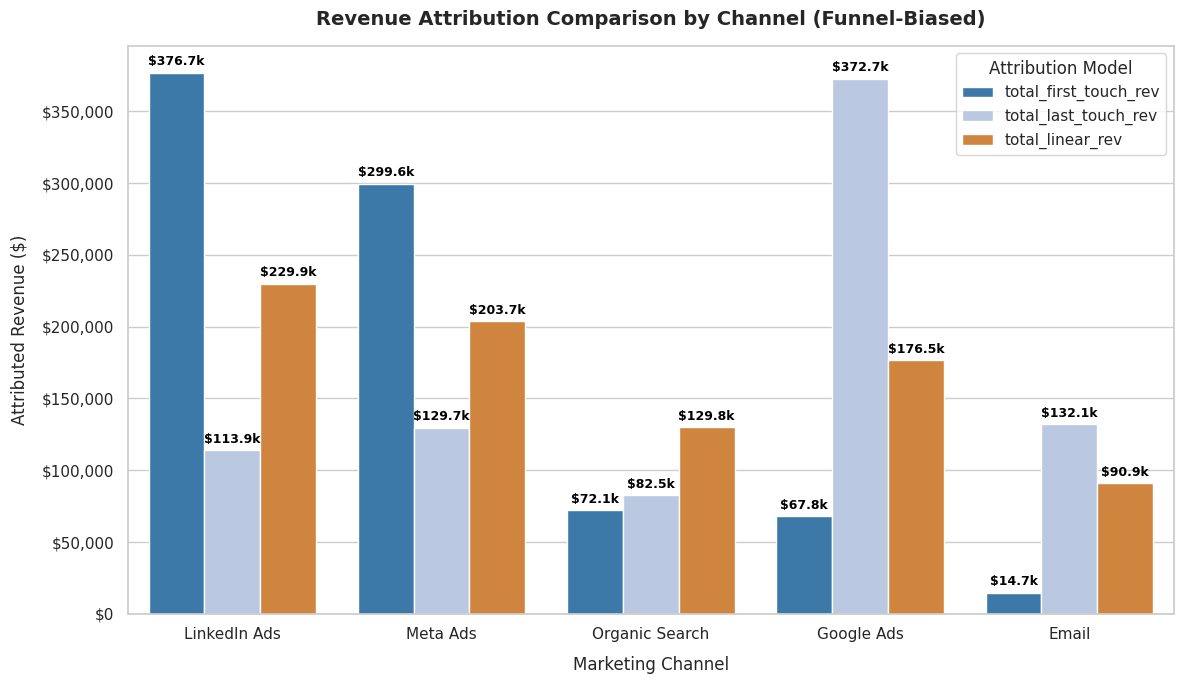

In [35]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


df = df.drop(columns='users_touched')
# 2. Sort the data by First-Touch in descending order
df = df.sort_values(by='total_first_touch_rev', ascending=False)

# 3. Melt the dataframe to format it correctly for Seaborn's grouped bar plot
df_melted = df.melt(id_vars='channel',
                    var_name='Attribution Model',
                    value_name='Attributed Revenue ($)')

# 4. Set up the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 5. Create the grouped bar plot
ax = sns.barplot(
    data=df_melted,
    x='channel',
    y='Attributed Revenue ($)',
    hue='Attribution Model',
    palette=['#2b7bba', '#b4c6e7', '#e88427'] # Custom professional color palette
)

# 6. Apply formatting and labels
plt.title('Revenue Attribution Comparison by Channel (Funnel-Biased)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Marketing Channel', fontsize=12, labelpad=10)
plt.ylabel('Attributed Revenue ($)', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)

# Format the y-axis to show currency with commas
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# 7. Add data labels on top of each bar for a polished look
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"${height/1000:.1f}k",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9, color='black', fontweight='semibold')

plt.tight_layout()
plt.show()